In [1]:
# import the required library
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing  import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score



In [2]:
# import data set
df = pd.read_csv("stroke.csv")
df = df.drop(df.columns[0], axis = 1)

In [3]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,90001,Female,77.0,1,0,Yes,Self-employed,Rural,176.71,33.2,never smoked,0
1,90002,Male,18.0,0,0,No,Private,Urban,80.07,22.3,Unknown,0
2,90003,Male,11.0,0,0,No,children,Rural,56.33,18.1,Unknown,0
3,90004,Female,16.0,0,0,No,Private,Urban,87.16,28.2,never smoked,0
4,90005,Female,73.0,0,1,Yes,Private,Rural,102.46,29.7,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...
22415,112416,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
22416,112417,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
22417,112418,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
22418,112419,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,90001,Female,77.0,1,0,Yes,Self-employed,Rural,176.71,33.2,never smoked,0
1,90002,Male,18.0,0,0,No,Private,Urban,80.07,22.3,Unknown,0
2,90003,Male,11.0,0,0,No,children,Rural,56.33,18.1,Unknown,0
3,90004,Female,16.0,0,0,No,Private,Urban,87.16,28.2,never smoked,0
4,90005,Female,73.0,0,1,Yes,Private,Rural,102.46,29.7,never smoked,0


In [6]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", len(df.drop_duplicates()))

Total rows: 22420
Duplicate rows: 0
Unique rows: 22420


In [7]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
22415,112416,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
22416,112417,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
22417,112418,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
22418,112419,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
22419,112420,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [8]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  859
smoking_status         0
stroke                 0
dtype: int64

In [9]:
# drop the null value

df = df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21561 entries, 0 to 22419
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 21561 non-null  int64  
 1   gender             21561 non-null  object 
 2   age                21561 non-null  float64
 3   hypertension       21561 non-null  int64  
 4   heart_disease      21561 non-null  int64  
 5   ever_married       21561 non-null  object 
 6   work_type          21561 non-null  object 
 7   Residence_type     21561 non-null  object 
 8   avg_glucose_level  21561 non-null  float64
 9   bmi                21561 non-null  float64
 10  smoking_status     21561 non-null  object 
 11  stroke             21561 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 2.1+ MB


In [11]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['work_type'] = le.fit_transform(df['work_type'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df['smoking_status'] = le.fit_transform(df['smoking_status'])

C:\Users\Bryson\AppData\Local\Temp\ipykernel_21564\2739015878.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gender'] = le.fit_transform(df['gender'])
C:\Users\Bryson\AppData\Local\Temp\ipykernel_21564\2739015878.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ever_married'] = le.fit_transform(df['ever_married'])
C:\Users\Bryson\AppData\Local\Temp\ipykernel_21564\2739015878.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

In [12]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,90001,0,77.0,1,0,1,3,0,176.71,33.2,2,0
1,90002,1,18.0,0,0,0,2,1,80.07,22.3,0,0
2,90003,1,11.0,0,0,0,4,0,56.33,18.1,0,0
3,90004,0,16.0,0,0,0,2,1,87.16,28.2,2,0
4,90005,0,73.0,0,1,1,2,0,102.46,29.7,2,0


In [13]:
df = df.drop('id', axis=1)

In [14]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,77.0,1,0,1,3,0,176.71,33.2,2,0
1,1,18.0,0,0,0,2,1,80.07,22.3,0,0
2,1,11.0,0,0,0,4,0,56.33,18.1,0,0
3,0,16.0,0,0,0,2,1,87.16,28.2,2,0
4,0,73.0,0,1,1,2,0,102.46,29.7,2,0
...,...,...,...,...,...,...,...,...,...,...,...
22414,0,13.0,0,0,0,4,0,103.08,18.6,0,0
22416,0,81.0,0,0,1,3,1,125.20,40.0,2,0
22417,0,35.0,0,0,1,3,0,82.99,30.6,2,0
22418,1,51.0,0,0,1,2,0,166.29,25.6,1,0


In [15]:
scaler = StandardScaler()

X = df.drop('stroke', axis=1)
y = df['stroke']

X_scaled = scaler.fit_transform(X)

In [16]:
print(df['stroke'].value_counts())

stroke
0    20725
1      836
Name: count, dtype: int64


In [17]:

sm = SMOTE(random_state=42)
X_scaled, y = sm.fit_resample(X_scaled, y)

print(y.value_counts())

stroke
0    20725
1    20725
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (33160, 10)
Testing size: (8290, 10)


In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [20]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost Model trained successfully!")

XGBoost Model trained successfully!


In [21]:
# Random Forest Evaluation
print("=== Random Forest ===")
y_pred_rf = model.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

# XGBoost Evaluation
print("=== XGBoost ===")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4199
           1       1.00      1.00      1.00      4091

    accuracy                           1.00      8290
   macro avg       1.00      1.00      1.00      8290
weighted avg       1.00      1.00      1.00      8290

ROC-AUC Score: 0.999999301436497
=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4199
           1       0.99      1.00      0.99      4091

    accuracy                           0.99      8290
   macro avg       0.99      0.99      0.99      8290
weighted avg       0.99      0.99      0.99      8290

ROC-AUC Score: 0.9997597523685523


In [22]:
# Single fake patient
# [gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status]
fake_patient = np.array([[1, 67.0, 0, 1, 1, 2, 1, 228.69, 36.6, 1]])

# Scale it first
fake_patient_scaled = scaler.transform(fake_patient)

# Predict
result = xgb_model.predict(fake_patient_scaled)
print("Prediction:", "Stroke ⚠️" if result[0] == 1 else "No Stroke ✅")

Prediction: Stroke ⚠️


C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
# Pick 5 random samples from the original data
sample = X_test[:5]
sample_labels = y_test[:5].values

# Predict
sample_pred = xgb_model.predict(sample)

# Compare
for i in range(5):
    actual = "Stroke ⚠️" if sample_labels[i] == 1 else "No Stroke ✅"
    predicted = "Stroke ⚠️" if sample_pred[i] == 1 else "No Stroke ✅"
    print(f"Sample {i+1} → Actual: {actual} | Predicted: {predicted}")

Sample 1 → Actual: No Stroke ✅ | Predicted: No Stroke ✅
Sample 2 → Actual: No Stroke ✅ | Predicted: No Stroke ✅
Sample 3 → Actual: Stroke ⚠️ | Predicted: Stroke ⚠️
Sample 4 → Actual: Stroke ⚠️ | Predicted: Stroke ⚠️
Sample 5 → Actual: No Stroke ✅ | Predicted: No Stroke ✅


In [24]:
import joblib

# Export the model
joblib.dump(xgb_model, 'stroke_model.pkl')

# Export the scaler
joblib.dump(scaler, 'scaler.pkl')

# Export the label encoder
joblib.dump(le, 'label_encoder.pkl')

print("All components exported successfully! ✅")

All components exported successfully! ✅


In [25]:
# Check what the model actually learned
print("Classes:", xgb_model.classes_)

# Test with a clearly LOW risk patient
import numpy as np

low_risk = np.array([[1, 25.0, 0, 0, 1, 3, 1, 80.0, 22.0, 2]])  # young, healthy female
low_scaled = scaler.transform(low_risk)
proba = xgb_model.predict_proba(low_scaled)

print("Low risk probabilities:", proba)
print("Prediction:", xgb_model.predict(low_scaled))

# Test with HIGH risk patient
high_risk = np.array([[0, 82.0, 1, 1, 1, 4, 0, 275.0, 42.0, 3]])
high_scaled = scaler.transform(high_risk)
proba2 = xgb_model.predict_proba(high_scaled)

print("High risk probabilities:", proba2)
print("Prediction:", xgb_model.predict(high_scaled))

Classes: [0 1]
Low risk probabilities: [[9.9990040e-01 9.9605044e-05]]
Prediction: [0]
High risk probabilities: [[9.9973023e-01 2.6974082e-04]]
Prediction: [0]


C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
# Check feature importance for Random Forest
import pandas as pd

feature_names = ['gender', 'age', 'hypertension', 'heart_disease', 
                 'ever_married', 'work_type', 'Residence_type', 
                 'avg_glucose_level', 'bmi', 'smoking_status']

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(importance)
print()

# Test low risk
low_risk = np.array([[1, 25.0, 0, 0, 1, 3, 1, 80.0, 22.0, 2]])
low_scaled = scaler.transform(low_risk)
proba_low = model.predict_proba(low_scaled)
print("Low risk probabilities:", proba_low)
print("Low risk prediction:", model.predict(low_scaled))
print()

# Test high risk
high_risk = np.array([[0, 82.0, 1, 1, 1, 4, 0, 275.0, 42.0, 3]])
high_scaled = scaler.transform(high_risk)
proba_high = model.predict_proba(high_scaled)
print("High risk probabilities:", proba_high)
print("High risk prediction:", model.predict(high_scaled))
print()

# Check class distribution
print("y value counts:", y.value_counts())
print("Model classes:", model.classes_)

Feature Importances:
             feature  importance
1                age    0.366826
7  avg_glucose_level    0.179494
8                bmi    0.160922
9     smoking_status    0.074062
5          work_type    0.064805
4       ever_married    0.047481
2       hypertension    0.035565
6     Residence_type    0.026815
0             gender    0.026033
3      heart_disease    0.017996

Low risk probabilities: [[1. 0.]]
Low risk prediction: [0]

High risk probabilities: [[0.89 0.11]]
High risk prediction: [0]

y value counts: stroke
0    20725
1    20725
Name: count, dtype: int64
Model classes: [0 1]


C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

# ── Step 1: Separate features and target BEFORE SMOTE ──
X = df.drop('stroke', axis=1)
y = df['stroke']

# ── Step 2: Split FIRST then SMOTE (correct way) ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── Step 3: Scale BEFORE SMOTE ──
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Step 4: Apply SMOTE only on training data ──
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", y_train_res.value_counts())

# ── Step 5: Retrain with better parameters ──
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# ── Step 6: Evaluate ──
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))

# ── Step 7: Test manually ──
low_risk  = np.array([[1, 25.0, 0, 0, 1, 3, 1, 80.0, 22.0, 2]])
high_risk = np.array([[0, 82.0, 1, 1, 1, 4, 0, 275.0, 42.0, 3]])

low_scaled  = scaler.transform(low_risk)
high_scaled = scaler.transform(high_risk)

print("Low risk proba:",  model.predict_proba(low_scaled))
print("High risk proba:", model.predict_proba(high_scaled))

# ── Step 8: Export ──
joblib.dump(model,  'stroke_model.pkl')
joblib.dump(scaler, 'stroke_scaler.pkl')
print("Exported successfully!")

After SMOTE: stroke
0    16579
1    16579
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4146
           1       0.96      0.98      0.97       167

    accuracy                           1.00      4313
   macro avg       0.98      0.99      0.99      4313
weighted avg       1.00      1.00      1.00      4313

ROC-AUC: 0.9999740027903671
Low risk proba: [[0.98808333 0.01191667]]


C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


High risk proba: [[0.81052177 0.18947823]]
Exported successfully!


In [28]:
import pandas as pd

feature_names = ['gender', 'age', 'hypertension', 'heart_disease', 
                 'ever_married', 'work_type', 'Residence_type', 
                 'avg_glucose_level', 'bmi', 'smoking_status']

# ── Test with proper DataFrame (matches scaler) ──
low_risk_df = pd.DataFrame([[1, 25.0, 0, 0, 1, 3, 1, 80.0, 22.0, 2]], columns=feature_names)
high_risk_df = pd.DataFrame([[0, 82.0, 1, 1, 1, 4, 0, 275.0, 42.0, 3]], columns=feature_names)
medium_risk_df = pd.DataFrame([[1, 55.0, 1, 0, 1, 3, 1, 140.0, 30.0, 1]], columns=feature_names)

low_scaled    = scaler.transform(low_risk_df)
high_scaled   = scaler.transform(high_risk_df)
medium_scaled = scaler.transform(medium_risk_df)

print("Low risk proba:   ", model.predict_proba(low_scaled))
print("Medium risk proba:", model.predict_proba(medium_scaled))
print("High risk proba:  ", model.predict_proba(high_scaled))

print()
print("Low prediction:   ", "Stroke" if model.predict(low_scaled)[0] == 1 else "No Stroke")
print("Medium prediction:", "Stroke" if model.predict(medium_scaled)[0] == 1 else "No Stroke")
print("High prediction:  ", "Stroke" if model.predict(high_scaled)[0] == 1 else "No Stroke")

Low risk proba:    [[0.98808333 0.01191667]]
Medium risk proba: [[0.86179795 0.13820205]]
High risk proba:   [[0.81052177 0.18947823]]

Low prediction:    No Stroke
Medium prediction: No Stroke
High prediction:   No Stroke


In [30]:
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
import numpy as np

feature_names = ['gender', 'age', 'hypertension', 'heart_disease',
                 'ever_married', 'work_type', 'Residence_type',
                 'avg_glucose_level', 'bmi', 'smoking_status']

# ── Step 1: Find best threshold ──
from sklearn.metrics import precision_recall_curve

y_proba = stroke_model_xgb.predict_proba(X_test_scaled)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold where recall >= 0.85
best_threshold = 0.5
for p, r, t in zip(precisions, recalls, thresholds):
    if r >= 0.85 and p >= 0.50:
        best_threshold = t
        break

print(f"Best threshold: {best_threshold:.4f}")

# ── Step 2: Check probabilities of test patients ──
low_risk_df    = pd.DataFrame([[1, 25.0, 0, 0, 0, 3, 1, 80.0, 22.0, 2]],  columns=feature_names)
medium_risk_df = pd.DataFrame([[1, 55.0, 1, 0, 1, 3, 1, 140.0, 30.0, 1]], columns=feature_names)
high_risk_df   = pd.DataFrame([[0, 82.0, 1, 1, 1, 4, 0, 275.0, 42.0, 3]], columns=feature_names)

for label, df_test in [("Low", low_risk_df), ("Medium", medium_risk_df), ("High", high_risk_df)]:
    scaled = scaler_stroke.transform(df_test)
    proba  = stroke_model_xgb.predict_proba(scaled)[0][1]
    print(f"{label} → raw proba: {proba:.6f}")

# ── Step 3: Find actual min and max proba in test set ──
print(f"\nMin proba in test set: {y_proba.min():.6f}")
print(f"Max proba in test set: {y_proba.max():.6f}")
print(f"Mean proba stroke=1 cases: {y_proba[y_test==1].mean():.6f}")
print(f"Mean proba stroke=0 cases: {y_proba[y_test==0].mean():.6f}")

Best threshold: 0.4166
Low → raw proba: 0.000372
Medium → raw proba: 0.083285
High → raw proba: 0.031586

Min proba in test set: 0.000024
Max proba in test set: 0.988042
Mean proba stroke=1 cases: 0.929783
Mean proba stroke=0 cases: 0.067585


In [31]:
# ── Find real HIGH risk patients from the dataset ──
import pandas as pd

feature_names = ['gender', 'age', 'hypertension', 'heart_disease',
                 'ever_married', 'work_type', 'Residence_type',
                 'avg_glucose_level', 'bmi', 'smoking_status']

# Get probabilities for entire test set
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_df['actual_stroke'] = y_test.values
X_test_df['stroke_proba']  = stroke_model_xgb.predict_proba(X_test_scaled)[:,1]

# Show actual HIGH risk patients (stroke=1, high proba)
high_risk_real = X_test_df[X_test_df['actual_stroke'] == 1].sort_values('stroke_proba', ascending=False)
print("=== REAL HIGH RISK PATIENTS (stroke=1) ===")
print(high_risk_real.head(3).to_string())

print()

# Show real LOW risk patients (stroke=0, low proba)
low_risk_real = X_test_df[X_test_df['actual_stroke'] == 0].sort_values('stroke_proba', ascending=True)
print("=== REAL LOW RISK PATIENTS (stroke=0) ===")
print(low_risk_real.head(3).to_string())

print()

# Show medium risk
medium_risk_real = X_test_df[X_test_df['actual_stroke'] == 1].sort_values(
    by='stroke_proba', ascending=False
)
mid = len(medium_risk_real) // 2
print("=== REAL MEDIUM RISK PATIENTS ===")
print(medium_risk_real.iloc[mid:mid+3].to_string())

=== REAL HIGH RISK PATIENTS (stroke=1) ===
       gender   age  hypertension  heart_disease  ever_married  work_type  Residence_type  avg_glucose_level   bmi  smoking_status  actual_stroke  stroke_proba
12393       1  68.0             1              1             1          2               0             271.74  31.1               3              1      0.988042
2200        1  81.0             1              1             1          2               1             250.89  28.1               3              1      0.987084
12420       1  81.0             1              1             1          2               1             250.89  28.1               3              1      0.987084

=== REAL LOW RISK PATIENTS (stroke=0) ===
       gender   age  hypertension  heart_disease  ever_married  work_type  Residence_type  avg_glucose_level   bmi  smoking_status  actual_stroke  stroke_proba
21313       0  24.0             0              0             0          2               0             147.74  21.4

In [20]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000
mean,101217.139882,42.732721,0.090951,0.048282,105.082362,28.861556,0.038774
std,6478.817752,22.542294,0.287546,0.214366,44.245321,7.845364,0.193060
min,90001.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,95608.000000,25.000000,0.000000,0.000000,76.980000,23.500000,0.000000
50%,101214.000000,44.000000,0.000000,0.000000,91.540000,28.000000,0.000000
75%,106815.000000,60.000000,0.000000,0.000000,113.250000,33.100000,0.000000
max,112420.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [22]:
# total number of patient
df["stroke"].value_counts()

stroke
0    20725
1      836
Name: count, dtype: int64

In [30]:
pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(x, y)

print(y_resampled.value_counts())

ImportError: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (C:\Users\Bryson\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py)

In [35]:
pip install scikit-learn==1.4.2
pip install imbalanced-learn==0.12.2

SyntaxError: invalid syntax (2513284136.py, line 1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


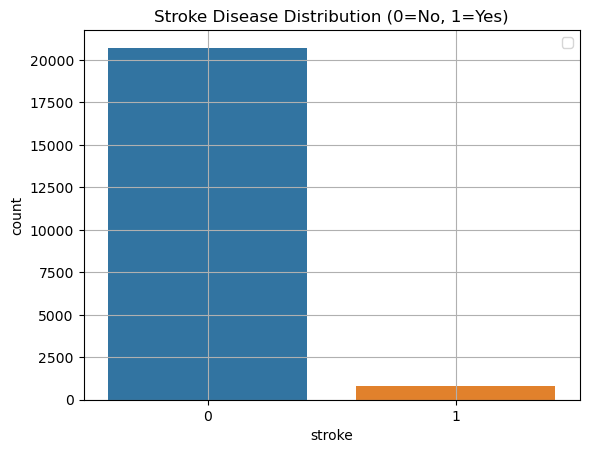

In [23]:
sns.countplot(x='stroke', data=df)
plt.title('Stroke Disease Distribution (0=No, 1=Yes)')
plt.legend()
plt.grid()
plt.show()

In [26]:
x = df.drop('stroke',axis = 1)
y = df['stroke']
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (21561, 11)
Target shape: (21561,)


In [27]:
# Split the dataset into training and testin set 

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [28]:
print(x_train.shape[0])
print( x_test.shape[0])

17248
4313


In [29]:
# perform the features scalling 

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

ValueError: could not convert string to float: 'Male'

In [40]:
print("Mean of scaled training data (should be close to 0):")
print(x_train_scaled.mean(axis=0).round(2))

Mean of scaled training data (should be close to 0):
[-0.  0. -0.  0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]


In [58]:
# train the ml models

# train random forest model
model_random = RandomForestClassifier(n_estimators = 100, random_state = 42)
model_random.fit(x_train_scaled, y_train)
y_pred = model_random.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 88.33%


In [42]:
# Train xboost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(x_train_scaled, y_train)
xgb_pred = xgb_model.predict(x_test_scaled)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred) * 100:.2f}%")

XGBoost Accuracy: 83.33%


In [45]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_scaled, y_train)
lr_pred = lr_model.predict(x_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")

Logistic Regression Accuracy: 86.67%


In [46]:
xgb_train_pred = xgb_model.predict(x_train_scaled)
print(f"XGBoost Training Accuracy: {accuracy_score(y_train, xgb_train_pred) * 100:.2f}%")
print(f"XGBoost Testing Accuracy:  {accuracy_score(y_test, xgb_pred) * 100:.2f}%")

XGBoost Training Accuracy: 100.00%
XGBoost Testing Accuracy:  83.33%


In [47]:
cm = confusion_matrix(y_test, xgb_pred)
print(cm)

[[29  7]
 [ 3 21]]


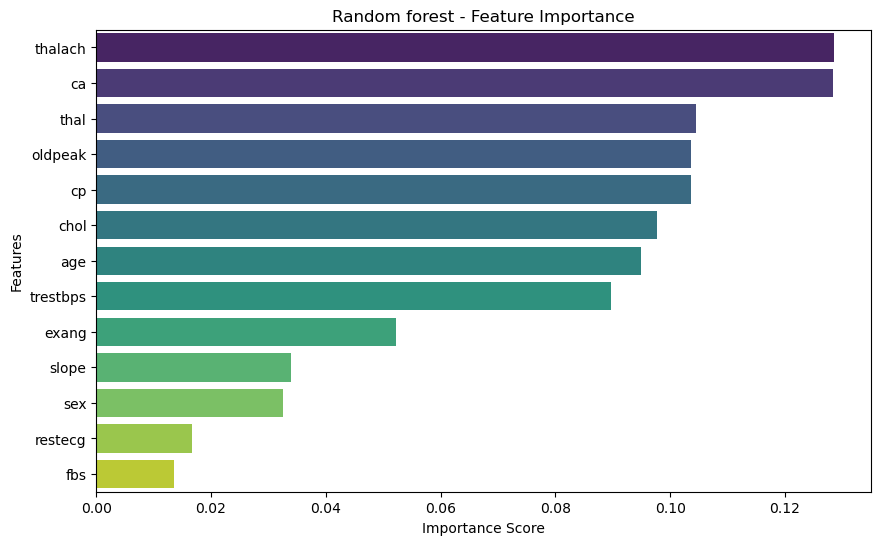

In [60]:
# plot features

feature_importance = pd.Series(model_random.feature_importances_, 
                                index=x.columns)
feature_importance_sorted = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_sorted.values, 
            y=feature_importance_sorted.index, 
            palette='viridis')
plt.title('Random forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [62]:
# save the model and scaller

import joblib

joblib.dump(model_random, "heart_disease_model.pkl")
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [63]:
new_patient = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'cp': [0],
    'trestbps': [125],
    'chol': [212],
    'fbs': [0],
    'restecg': [1],
    'thalach': [168],
    'exang': [0],
    'oldpeak': [1.0],
    'slope': [2],
    'ca': [2],
    'thal': [3]
})

In [51]:
new_patient_scaled = scaler.transform(new_patient)
prediction = xgb_model.predict(new_patient_scaled)
probability = xgb_model.predict_proba(new_patient_scaled)

print(f"Prediction: {'❤️ Heart Disease Detected' if prediction[0] == 1 else '✅ No Heart Disease'}")
print(f"Probability of Disease: {probability[0][1] * 100:.2f}%")
print(f"Probability of No Disease: {probability[0][0] * 100:.2f}%")

Prediction: ✅ No Heart Disease
Probability of Disease: 30.53%
Probability of No Disease: 69.47%


In [53]:
test_patients = pd.DataFrame({
    'age':      [35,  58,  67],
    'sex':      [0,   1,   1],
    'cp':       [3,   1,   0],
    'trestbps': [110, 130, 165],
    'chol':     [180, 230, 290],
    'fbs':      [0,   0,   1],
    'restecg':  [0,   1,   1],
    'thalach':  [175, 150, 108],
    'exang':    [0,   0,   1],
    'oldpeak':  [0.0, 1.2, 2.8],
    'slope':    [2,   1,   0],
    'ca':       [0,   1,   3],
    'thal':     [2,   2,   3]
}, index=['low_risk', 'medium_risk', 'high_risk'])

test_patients_scaled = scaler.transform(test_patients)
predictions = xgb_model.predict(test_patients_scaled)
probabilities = xgb_model.predict_proba(test_patients_scaled)

for i, name in enumerate(test_patients.index):
    print(f"{name}: prediction={predictions[i]}, "
          f"P(disease)={probabilities[i][1]*100:.2f}%")

low_risk: prediction=0, P(disease)=0.18%
medium_risk: prediction=1, P(disease)=97.73%
high_risk: prediction=1, P(disease)=95.43%


In [54]:
diabetes_flag_test = pd.DataFrame({
    'age':      [55,  55],
    'sex':      [1,   1],
    'cp':       [1,   1],
    'trestbps': [130, 130],
    'chol':     [230, 230],
    'fbs':      [0,   1],     # <- only this changes: 0 = fasting glucose normal, 1 = elevated
    'restecg':  [1,   1],
    'thalach':  [150, 150],
    'exang':    [0,   0],
    'oldpeak':  [1.0, 1.0],
    'slope':    [1,   1],
    'ca':       [1,   1],
    'thal':     [2,   2]
}, index=['fbs_normal', 'fbs_elevated'])

diabetes_flag_scaled = scaler.transform(diabetes_flag_test)
preds = xgb_model.predict(diabetes_flag_scaled)
probs = xgb_model.predict_proba(diabetes_flag_scaled)

for i, name in enumerate(diabetes_flag_test.index):
    print(f"{name}: prediction={preds[i]}, P(disease)={probs[i][1]*100:.2f}%")

fbs_normal: prediction=1, P(disease)=88.03%
fbs_elevated: prediction=1, P(disease)=58.10%


In [55]:
print(len(df))

297


In [64]:
# made the prediction using the random forest model

sample_patient = [[
    67,    # age
    1,     # sex (male)
    4,     # asymptomatic chest pain
    160,   # resting blood pressure
    286,   # cholesterol
    1,     # fasting blood sugar > 120
    2,     # abnormal ECG
    108,   # low max heart rate
    1,     # exercise-induced angina
    2.5,   # ST depression
    2,     # flat slope
    3,     # 3 major vessels
    7      # reversible defect
]]

In [65]:
prediction = model_random.predict(sample_patient)

In [66]:
print(prediction)

[1]
